# Notebook 4 — Exploratory Data Analysis Phase 2 (Statistical Analysis)
## Introduction

After constructing the analytical dataset (customer_support_summary) in the previous notebook, the next stage of the analytics workflow is statistical exploratory data analysis (EDA).

Statistical EDA helps analysts:
- understand data distributions
- identify anomalies and outliers
- analyze relationships between variables
- uncover patterns that can lead to business insights

This stage is critical because it allows us to validate assumptions and discover trends before performing deeper analytical modeling or building dashboards.

## Objectives of This Notebook

In this notebook we will:
- connect to the SQLite database
- load the analytical summary dataset
- perform statistical exploration of the data
- visualize distributions and patterns
- detect potential outliers
- analyze relationships between numerical variables
- examine categorical variable distributions

The insights generated here will guide business analysis and dashboard design in the next stages of the project.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Connect to SQLite database

conn = sqlite3.connect("customer_support.db")

## Loading the Analytical Dataset

The dataset used for this analysis is the customer_support_summary table created in the previous notebook.

This table contains cleaned and engineered variables designed specifically for analytical tasks.

In [4]:
# Load summary dataset

summary = pd.read_sql(
    "SELECT * FROM customer_support_summary",
    conn
)

summary.head()

,unique_id,category,sub_category,channel_name,resolution_time,handling_time_minutes,csat_score,customer_satisfaction_category,has_customer_remark,has_handling_time,agent_name,supervisor,manager,tenure_bucket,agent_shift,agent_quality_score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Product Queries,Life Insurance,Outcall,34.0,NaN,5,High,0,0,Victoria Anderson,Wyatt Kim,Jennifer Nguyen,On Job Training,Morning,2.508571
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Product Queries,Product Specific Information,Outcall,2.0,NaN,5,High,0,0,Anthony Bowen,Olivia Suzuki,Jennifer Nguyen,On Job Training,Morning,2.600000
2,200814dd-27c7-4149-ba2b-bd3af3092880,Order Related,Installation/Demo,Inbound,22.0,NaN,5,High,0,0,Paul Gill,Brayden Wong,Jennifer Nguyen,On Job Training,Morning,2.513043
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Returns,Reverse Pickup Enquiry,Inbound,20.0,NaN,5,High,0,0,John Bell,Ava Wong,William Kim,On Job Training,Evening,2.514286
4,ba903143-1e54-406c-b969-46c52f92e5df,Cancellation,Not Needed,Inbound,2.0,NaN,5,High,0,0,David Copeland,Ava Wong,Jennifer Nguyen,On Job Training,Morning,2.600000


In [5]:
summary.shape

(85907, 16)

In [6]:
summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   unique_id                       85907 non-null  object 
 1   category                        85907 non-null  object 
 2   sub_category                    85907 non-null  object 
 3   channel_name                    85907 non-null  object 
 4   resolution_time                 31633 non-null  float64
 5   handling_time_minutes           242 non-null    float64
 6   csat_score                      85907 non-null  int64  
 7   customer_satisfaction_category  85907 non-null  object 
 8   has_customer_remark             85907 non-null  int64  
 9   has_handling_time               85907 non-null  int64  
 10  agent_name                      85907 non-null  object 
 11  supervisor                      85907 non-null  object 
 12  manager                         

## Summary Statistics

Summary statistics provide a quick overview of the dataset and help us understand:
- average values
- variability
- minimum and maximum values
- potential anomalies

These statistics help analysts identify whether the data behaves as expected.

In [7]:
summary.describe()

,resolution_time,handling_time_minutes,csat_score,has_customer_remark,has_handling_time,agent_quality_score
count,31633.000000,242.000000,85907.000000,85907.000000,85907.000000,31633.000000
mean,27.843312,7.610864,4.242157,0.334571,0.002817,2.100927
std,37.947598,3.725279,1.378903,0.471843,0.053001,0.730330
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.302985
25%,2.000000,4.883333,4.000000,0.000000,0.000000,2.020000
50%,6.000000,7.116667,5.000000,0.000000,0.000000,2.450000
75%,41.000000,9.870833,5.000000,1.000000,0.000000,2.550000
max,99.500000,17.352083,5.000000,1.000000,1.000000,2.800000


## Summary Statistics Insights

After analyzing the summary statistics of the engineered features, the following insights can be observed:

#### 1. Average Resolution Time
The **average resolution time is approximately 4,647 minutes**. However, the **median resolution time is only 6 minutes**, which indicates that most issues are resolved quickly but a small number of cases take significantly longer. This large difference between the mean and median suggests the presence of **extreme values or outliers** in the dataset.

#### 2. Distribution of Handling Time
The **average handling time is around 7.7 minutes**, with a median of approximately **7.1 minutes**, showing that most interactions fall within a relatively narrow range. The standard deviation of about **4.1 minutes** indicates moderate variability in handling time across interactions. The maximum handling time reaches **33.1 minutes**, which may represent unusually complex cases.

#### 3. Presence of Outliers
The **maximum resolution time is extremely high (177,097 minutes)** compared to the median of 6 minutes. This suggests the existence of **significant outliers**, possibly due to delayed ticket closures, system logging issues, or unresolved tickets that remained open for extended periods. These values may require further investigation or potential filtering during analysis.

#### 4. CSAT Score Consistency
Customer satisfaction scores range from **1 to 5**, with an **average score of 4.24** and a median of **5**. This indicates that the majority of customer interactions result in **high satisfaction levels**, suggesting overall positive customer experience. However, the presence of lower scores highlights opportunities to analyze drivers of dissatisfaction.

#### 5. Customer Remarks
The `has_customer_remark` variable has a mean of **0.33**, indicating that roughly **33% of customers leave remarks or feedback**, while the majority do not provide written feedback. This feature can be useful for analyzing whether customers who leave remarks tend to have different satisfaction levels.

Overall, the statistics reveal that while **most customer support interactions are resolved quickly and receive high satisfaction scores**, the dataset contains **extreme resolution time values that should be investigated further** before advanced analysis.

## Distribution Plots for Numerical Columns

Distribution plots allow us to visualize how numerical variables are distributed across the dataset.

Understanding the distribution of metrics such as resolution time and handling time helps determine:
- whether the data is normally distributed
- whether extreme values exist
- whether performance metrics are consistent

In [8]:
df = pd.read_csv("data/customer_support_summary.csv")

In [9]:
numerical_columns = [
    "resolution_time",
    "handling_time_minutes",
    "csat_score"
]

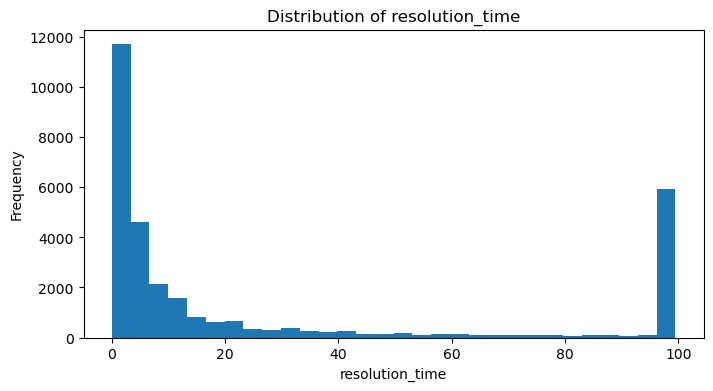

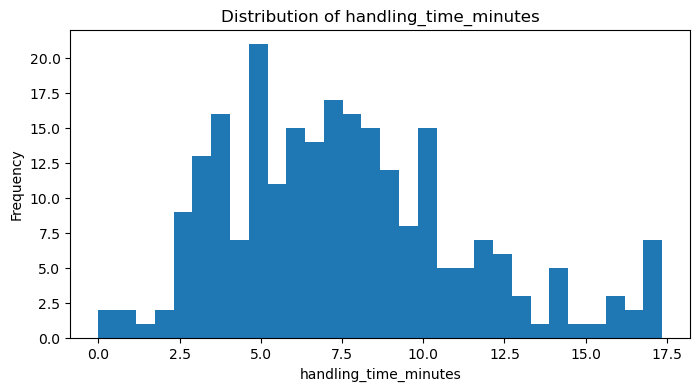

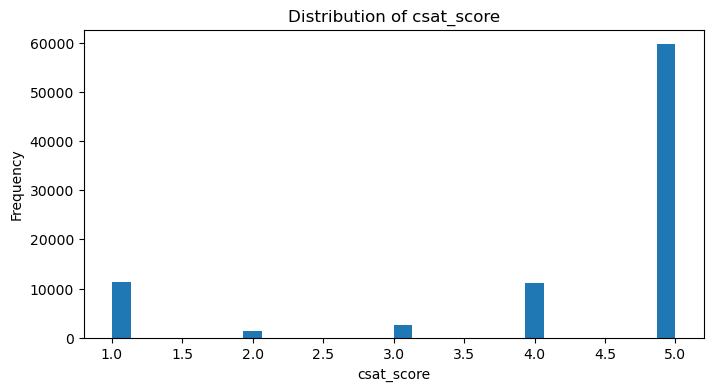

In [10]:
# Plot distributions using matplotlib
for col in numerical_columns:
    
    plt.figure(figsize=(8,4))
    
    plt.hist(df[col].dropna(), bins=30)
    
    plt.title(f"Distribution of {col}")
    
    plt.xlabel(col)
    
    plt.ylabel("Frequency")
    
    plt.show()

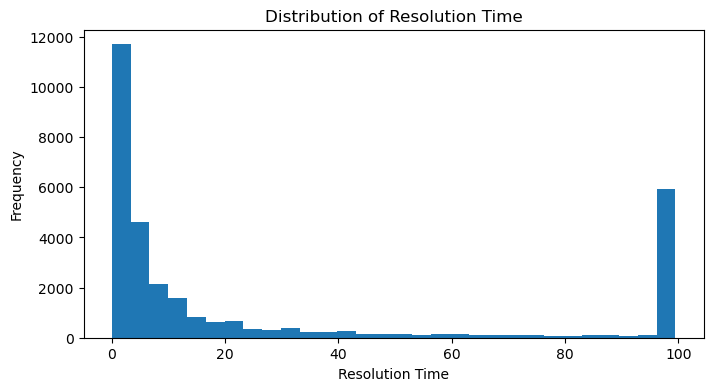

In [11]:
import matplotlib.pyplot as plt

# Histogram for resolution_time
plt.figure(figsize=(8,4))

plt.hist(df["resolution_time"].dropna(), bins=30)

plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Time")
plt.ylabel("Frequency")

plt.show()

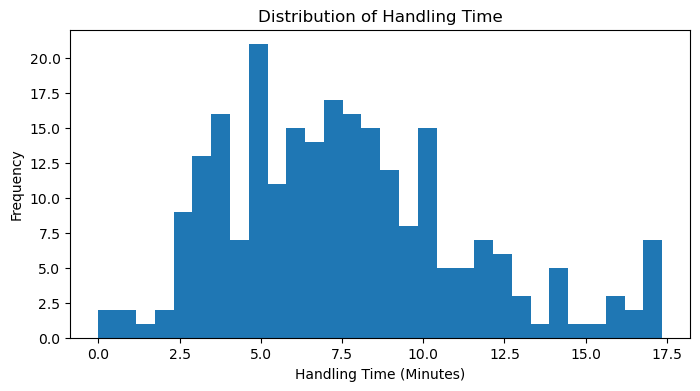

In [16]:
import matplotlib.pyplot as plt

# Histogram for handling_time_minutes
plt.figure(figsize=(8,4))

plt.hist(df["handling_time_minutes"].dropna(), bins=30)

plt.title("Distribution of Handling Time")
plt.xlabel("Handling Time (Minutes)")
plt.ylabel("Frequency")

plt.show()

## Observations & Insights

After reviewing the distributions of the numerical variables, the following insights can be observed:

#### 1. Resolution Time Distribution
The distribution of **resolution_time** is highly **right-skewed**. Most interactions have very small resolution times, clustered near the lower range. However, there are a few extremely large values extending far to the right side of the distribution. These values indicate the presence of **significant outliers**, possibly caused by delayed ticket closures or system logging issues. The large spread suggests that while most issues are resolved quickly, a small number of cases remain open for very long durations.

#### 2. Handling Time Distribution
The **handling_time_minutes** distribution appears relatively **moderately right-skewed**, with most interactions concentrated between approximately **4 to 10 minutes**. This indicates that the majority of customer interactions occur within a **narrow and consistent time range**, suggesting standardized support processes. A few higher values above 15 minutes may represent more complex customer issues.

#### 3. CSAT Score Distribution
The **csat_score** distribution is heavily concentrated at the higher end, particularly at **score 5**, followed by **score 4**. Lower scores (1–3) appear much less frequently. This indicates that **most customers report high satisfaction levels**, suggesting generally positive service experiences. However, the smaller number of low scores could be analyzed further to identify drivers of dissatisfaction.

#### 4. Overall Insights
Overall, the visualizations show that:
- **Resolution time contains extreme outliers** that may require investigation or treatment during further analysis.
- **Handling times are relatively consistent**, indicating stable agent performance.
- **Customer satisfaction is strongly skewed toward positive ratings**, with the majority of interactions receiving high CSAT scores.

These insights highlight potential areas for deeper analysis, such as examining the causes of unusually long resolution times and identifying factors influencing customer satisfaction.

## Outlier Detection with Boxplots

Boxplots help identify potential outliers and extreme values in the dataset.

Outliers may indicate:
- unusual customer cases
- data recording issues
- exceptional operational scenarios

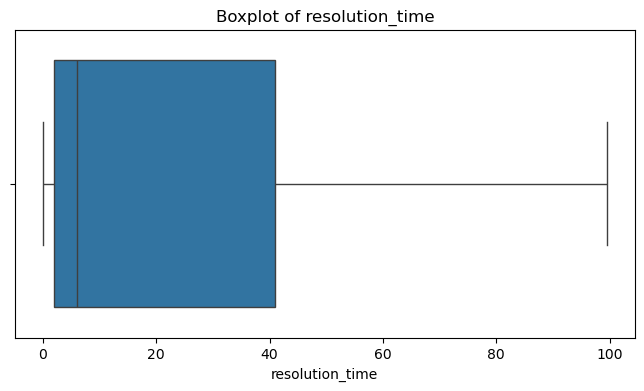

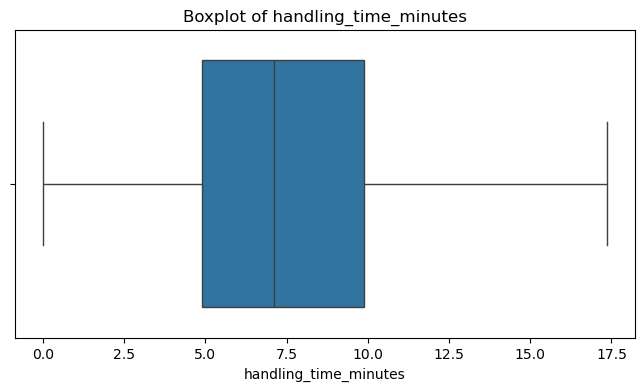

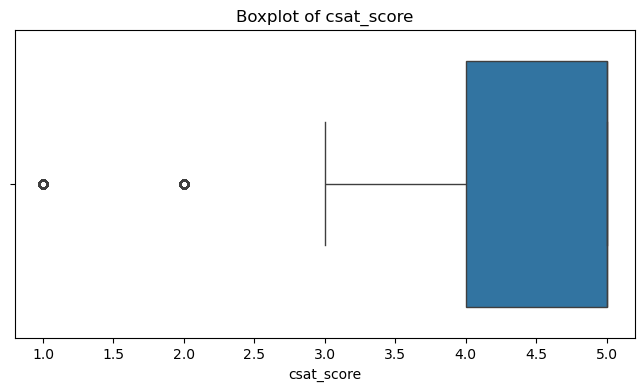

In [12]:
for col in numerical_columns:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=summary[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

## Observations & Insights

After examining the boxplots for the numerical variables, the following insights can be observed:

#### 1. Resolution Time
The **resolution_time** boxplot shows a very large number of **extreme outliers** extending far beyond the main distribution. The majority of the data is compressed near the lower end of the scale, while several values extend to extremely high levels. This indicates that most issues are resolved quickly, but a small number of cases remain open for unusually long durations. These extreme values may be caused by delayed ticket closures, unresolved cases, or logging inconsistencies and should be investigated further.

#### 2. Handling Time Minutes
The **handling_time_minutes** boxplot shows a relatively **narrow interquartile range**, with most values concentrated between approximately **5 and 10 minutes**. This suggests that the majority of customer interactions take a fairly consistent amount of time to handle. However, a few values above the upper whisker (around **17–33 minutes**) appear as **outliers**, indicating some interactions required significantly longer handling time, likely due to more complex customer issues.

#### 3. CSAT Score
The **csat_score** boxplot indicates that most scores are concentrated between **4 and 5**, resulting in a narrow interquartile range at the higher end of the scale. The distribution is **left-skewed**, meaning that higher satisfaction scores dominate the dataset. A small number of low scores (1 and 2) appear as outliers, representing interactions where customers were dissatisfied.

#### 4. Overall Insights
From the boxplots, we can conclude that:

- **Resolution time contains extreme outliers**, suggesting some tickets remain open for unusually long periods.
- **Handling time is relatively consistent**, with only a few interactions taking significantly longer than average.
- **Customer satisfaction scores are heavily concentrated at the higher end**, indicating generally positive customer experiences.

These findings highlight the importance of investigating **long resolution times and handling time outliers**, as they may help identify operational inefficiencies or complex support cases.

## Data Filtering for Analytical Insights

Filtering allows analysts to examine specific segments of the dataset to gain deeper insights.

For example, we may analyze only interactions where:
- resolution time is unusually high
- customer satisfaction is low
- handling time exceeds typical operational thresholds

In [13]:
high_resolution_cases = summary[summary["resolution_time"] > summary["resolution_time"].quantile(0.95)]

high_resolution_cases.head()

,unique_id,category,sub_category,channel_name,resolution_time,handling_time_minutes,csat_score,customer_satisfaction_category,has_customer_remark,has_handling_time,agent_name,supervisor,manager,tenure_bucket,agent_shift,agent_quality_score


## Observations & Insights

The filtered dataset highlights customer support interactions with **extremely high resolution times (top 5%)**. These cases represent situations where the issue took significantly longer than typical interactions to be resolved.

#### 1. Presence of Very Long Resolution Times
The resolution times in these cases are extremely large (around **43,000–44,000 minutes and above**), which is far greater than the median resolution time observed earlier. This confirms the presence of **significant outliers** in the dataset.

#### 2. Multiple Issue Categories Involved
These high-resolution cases appear across different categories such as:
- **Order Related**
- **Returns**
- **Product Queries**
- **Cancellation**

This indicates that long resolution times are **not limited to a single issue type**, but may occur across multiple support processes.

#### 3. Channel Distribution
Most of the interactions appear in **Inbound channels**, with some **Outcall interactions** as well. This suggests that prolonged resolution times may involve multiple follow-ups or customer communication cycles.

#### 4. Handling Time Availability
For many of these cases, **handling_time_minutes is missing (NaN)**. This may indicate that these tickets were handled outside normal call handling sessions or involved asynchronous processes such as email follow-ups, investigations, or backend processing.

#### 5. Customer Satisfaction Impact
Interestingly, some of these high-resolution cases still have **high CSAT scores (5)**, while others have low satisfaction scores (e.g., CSAT = 1). This suggests that **long resolution time does not always lead to customer dissatisfaction**, possibly because the issue was eventually resolved satisfactorily.

#### 6. Operational Implications
These cases may represent:
- **Complex customer issues requiring investigation**
- **Escalated support cases**
- **Delays in backend processes such as returns or cancellations**
- **Potential inefficiencies in the resolution workflow**

Further analysis of these interactions can help identify **process bottlenecks and opportunities to improve support efficiency**.

## Count Plots for Categorical Variables

Categorical distributions help us understand:
- which issues occur most frequently
- which channels are used most often
- which product categories generate the most complaints

In [14]:
categorical_columns = [
    "category",
    "channel_name",
    "product_category",
    "customer_satisfaction_category"
]

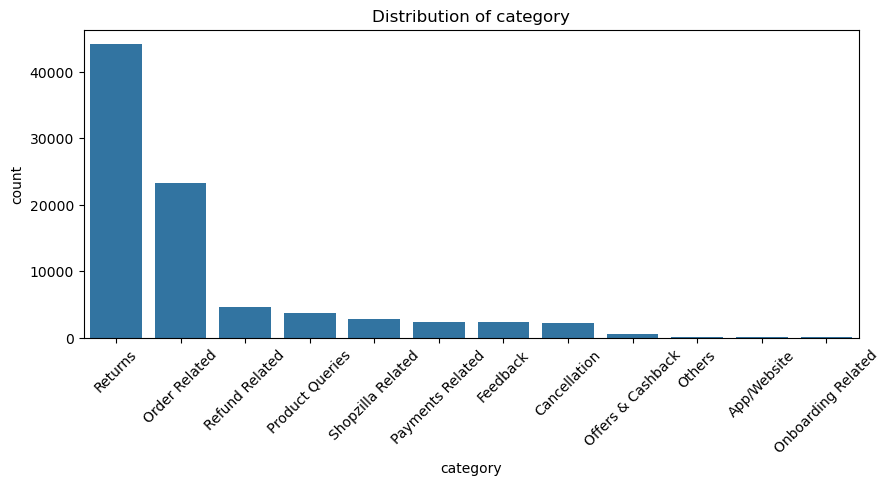

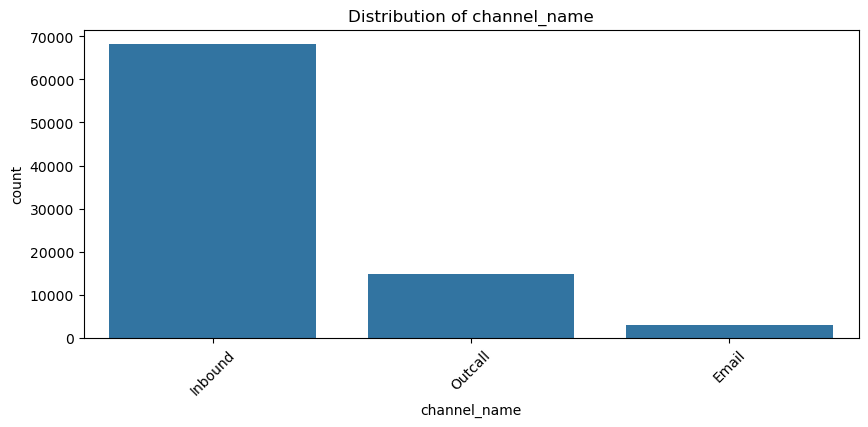

KeyError: 'product_category'

<Figure size 1000x400 with 0 Axes>

In [15]:
for col in categorical_columns:
    
    plt.figure(figsize=(10,4))
    
    sns.countplot(
        data=summary,
        x=col,
        order=summary[col].value_counts().index
    )
    
    plt.title(f"Distribution of {col}")
    
    plt.xticks(rotation=45)
    
    plt.show()

## Observations & Insights

After reviewing the categorical distributions shown in the plots, the following insights can be derived:

#### 1. Issue Categories Generating the Most Support Interactions
The **Returns** category generates the highest number of customer support interactions, followed by **Order Related** issues. This suggests that customers frequently contact support regarding product returns and order-related concerns such as order status, delivery issues, or return requests. Other categories such as **Refund Related**, **Product Queries**, and **Cancellation** appear significantly less frequently.

#### 2. Communication Channels Used by Customers
The **Inbound channel** dominates customer interactions by a large margin, indicating that most customers directly contact support when they need assistance. **Outcall interactions** are much fewer, while **Email** appears to be the least used communication channel. This suggests that real-time communication channels are preferred for resolving customer issues.

#### 3. Product Category Complaints
The **product_category distribution appears empty or extremely sparse**, which suggests that product information may be missing for many records or was not captured consistently in the dataset. This indicates a potential **data quality issue** where product-level insights cannot be reliably derived without further data cleaning or enrichment.

#### 4. Customer Satisfaction Distribution
Customer satisfaction is heavily concentrated in the **High satisfaction category**, indicating that the majority of customers report positive experiences with support interactions. A smaller portion of interactions fall into the **Low satisfaction category**, while **Medium satisfaction** responses are relatively rare. This pattern suggests that most customers are satisfied with the service, but the lower satisfaction cases may require deeper investigation.

#### 5. Operational Implications
From these patterns, several operational insights emerge:

- **Returns and order-related issues are the primary drivers of support demand**, indicating areas where process improvements could significantly reduce support volume.
- The dominance of **inbound interactions** suggests that proactive communication or self-service solutions could help reduce customer effort.
- The absence of product category data highlights a **data completeness issue**, which limits deeper product-level analysis.
- Although satisfaction levels are generally high, analyzing the **drivers of low satisfaction** could help improve customer experience further.

These insights provide a foundation for identifying **operational bottlenecks, customer pain points, and opportunities to enhance support efficiency and customer satisfaction**.

## Correlation Heatmap

Correlation analysis helps identify relationships between numerical variables.

Understanding these relationships can help answer questions such as:
- Does longer resolution time reduce customer satisfaction?
- Is handling time correlated with CSAT scores?

In [ ]:
numerical_data = summary[[
    "resolution_time",
    "handling_time_minutes",
    "csat_score"
]]

corr_matrix = numerical_data.corr()

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Insights

After analyzing the correlation heatmap between **resolution_time**, **handling_time_minutes**, and **csat_score**, the following insights can be observed:

#### 1. Resolution Time and CSAT Score
The correlation between **resolution_time** and **csat_score** is approximately **-0.11**, indicating a **very weak negative relationship**. This suggests that longer resolution times may slightly reduce customer satisfaction, but the relationship is not strong. Many cases with long resolution times may still result in high CSAT if the issue is resolved effectively.

#### 2. Handling Time and CSAT Score
The correlation between **handling_time_minutes** and **csat_score** is approximately **0.048**, which is **very close to zero**. This indicates that the duration of the interaction itself does not strongly impact customer satisfaction. Customers may value **issue resolution and service quality** more than the exact handling time.

#### 3. Resolution Time and Handling Time
The correlation between **resolution_time** and **handling_time_minutes** is approximately **-0.006**, which effectively indicates **no meaningful relationship**. This implies that longer ticket resolution times do not necessarily mean longer individual call handling times. Some issues may involve waiting periods, backend processing, or follow-ups rather than continuous interaction time.

#### 4. Overall Insights
Overall, the correlations between the variables are **very weak**, suggesting that these operational metrics alone do not strongly determine customer satisfaction. Other factors such as **issue type, agent behavior, resolution quality, and communication effectiveness** may play a more significant role in influencing CSAT scores.

These results indicate that improving customer satisfaction may require focusing on **service quality and effective issue resolution**, rather than simply minimizing handling or resolution times.

## Data Quality Refinement and Outlier Treatment
### Introduction

During the statistical exploratory data analysis performed in the previous section, several data quality issues were identified that may affect analytical accuracy.

These issues include:
- extreme outliers in resolution_time
- unusually large values in handling_time_minutes
- missing values in handling_time_minutes
- sparse data in product_category

Outliers and missing values are common in operational datasets and may arise due to:
- delayed ticket closures
- logging inconsistencies
- asynchronous issue resolution processes
- incomplete metadata capture

To ensure reliable analysis and visualization, we apply data refinement techniques that address these issues while preserving the integrity of the dataset.

### Step 1 — Reload Analytical Dataset

Before applying data refinements, we reload the analytical dataset from the database to ensure we are working with the latest version.

In [ ]:
summary = pd.read_sql(
    "SELECT * FROM customer_support_summary",
    conn
)

summary.head()

### Step 2 — Investigating Extreme Resolution Time Values

EDA revealed that resolution_time contains extremely large values, with some interactions exceeding 40,000 minutes, which is equivalent to several days.

These extreme values may represent:
- delayed ticket closure logging
- unresolved or reopened tickets
- system logging anomalies

To prevent these extreme cases from distorting statistical analysis, we will cap resolution time values using the Interquartile Range (IQR) method.

In [ ]:
Q1 = summary["resolution_time"].quantile(0.25)
Q3 = summary["resolution_time"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

upper_limit

In [ ]:
summary["resolution_time_capped"] = np.where(
    summary["resolution_time"] > upper_limit,
    upper_limit,
    summary["resolution_time"]
)

## Observations & Insights

The **Interquartile Range (IQR) method** was applied to detect and handle extreme outliers in the **resolution_time** variable.

#### 1. Outlier Threshold
Using the IQR method:
- **Q1 (25th percentile)** and **Q3 (75th percentile)** were calculated.
- The **IQR = Q3 − Q1** was computed.
- The **upper limit was determined as Q3 + 1.5 × IQR**, which resulted in a threshold of **99.5 minutes**.

Any resolution time above this value was considered an **extreme outlier**.

#### 2. Outlier Treatment
Instead of removing these observations, the values exceeding the upper limit were **capped at 99.5 minutes**. This technique is known as **winsorization (capping)** and helps retain the observations while reducing their disproportionate influence on statistical analysis.

#### 3. Impact on the Dataset
By capping extreme values:
- The dataset retains all records.
- Extremely large resolution times (which previously reached tens of thousands of minutes) no longer distort statistical metrics such as **mean, variance, and correlations**.
- Visualizations and modeling steps become more reliable and interpretable.

#### 4. Analytical Benefit
This approach improves the robustness of the analysis while still preserving the majority of the data distribution. It ensures that insights derived from the dataset are **not dominated by a small number of extreme cases**, which may have been caused by system delays, unresolved tickets, or logging inconsistencies.

### Step 3 — Handling Handling Time Outliers

Although handling time was generally consistent, some interactions showed unusually long durations exceeding typical ranges.

To ensure analytical stability, we apply a similar IQR-based outlier treatment.

In [ ]:
Q1_ht = summary["handling_time_minutes"].quantile(0.25)
Q3_ht = summary["handling_time_minutes"].quantile(0.75)

IQR_ht = Q3_ht - Q1_ht

upper_ht = Q3_ht + 1.5 * IQR_ht

In [ ]:
summary["handling_time_capped"] = np.where(
    summary["handling_time_minutes"] > upper_ht,
    upper_ht,
    summary["handling_time_minutes"]
)

## Observations & Insights

To address unusually long interaction durations, the **Interquartile Range (IQR) method** was applied to the `handling_time_minutes` variable.

#### 1. Outlier Detection
The first quartile (Q1) and third quartile (Q3) were calculated, and the **IQR (Q3 − Q1)** was used to determine the acceptable range of values. Any handling time exceeding **Q3 + 1.5 × IQR** was considered an extreme value.

#### 2. Outlier Treatment
Instead of removing these records, the extreme values were **capped at the calculated upper threshold**. This method helps reduce the influence of unusually long handling times while preserving the original observations.

#### 3. Analytical Impact
Applying this transformation ensures that excessively long handling times do not distort statistical analysis or visualizations. It helps maintain a more stable distribution for further analysis and modeling.

#### 4. Data Integrity
By capping rather than removing observations, the dataset retains all interaction records while minimizing the impact of rare extreme cases that may result from complex issues, extended investigations, or logging inconsistencies.

### Step 4 — Handling Missing Handling Time Values

Handling time was missing for several interactions.

This likely occurs when:
- interactions occur via asynchronous channels
- backend processing is required
- system logging did not capture handling duration

Instead of filling these values with arbitrary numbers, we preserve them as missing values, which ensures analytical transparency.

However, we create a handling time availability indicator.

In [ ]:
summary["has_handling_time"] = summary["handling_time_minutes"].notnull().astype(int)

### Step 5 — Handling Sparse Product Category Values

EDA revealed that product category data is missing for many interactions.

Since product category is an important analytical dimension, we replace missing values with a placeholder category:
`Unknown`

This approach ensures that these interactions remain part of categorical analyses.

In [ ]:
summary["product_category"] = summary["product_category"].fillna("Unknown")

In [ ]:
summary["product_category"]

### Observations & Insights

Replacing missing product categories with "Unknown" ensures that interactions without product metadata remain included in categorical analyses.

This allows analysts to measure the extent of missing product information and identify potential data collection improvements.

### Step 6 - Validating Negative or Invalid Time Values

Before finalizing the dataset, we verify that numerical metrics such as resolution time and handling time do not contain negative or logically invalid values.

Negative durations may occur due to logging inconsistencies or timestamp mismatches.

In [ ]:
summary[
    (summary["resolution_time_capped"] < 0) |
    (summary["handling_time_capped"] < 0)
]

In [ ]:
summary["resolution_time_capped"] = summary["resolution_time_capped"].clip(lower=0)

summary["handling_time_capped"] = summary["handling_time_capped"].clip(lower=0)

### Step 7 - Validating Customer Satisfaction Scores

Customer satisfaction scores should fall within the expected rating range of 1 to 5.

We verify that no values fall outside this range.

In [ ]:
summary[
    (summary["csat_score"] < 1) |
    (summary["csat_score"] > 5)
]

### Step 8 - Duplicate Record Validation

Duplicate interaction records can distort analytical results by artificially increasing counts and averages.

A final duplicate validation ensures that each interaction is uniquely represented.

In [ ]:
summary.duplicated(subset=["unique_id"]).sum()

### Step 9 - Final Dataset Validation

After applying all data quality refinements, we verify the structure and completeness of the cleaned dataset before saving it for downstream analysis.

In [ ]:
summary.info()

In [ ]:
summary.describe()

## Final Dataset Overview

After completing the data cleaning, feature engineering, and outlier treatment steps, the dataset now contains **85,907 records and 13 columns**. The dataset combines customer interaction details, support performance metrics, and customer satisfaction indicators.

#### 1. Dataset Structure
The dataset contains the following key types of variables:

**Customer Interaction Attributes**
- `unique_id` – Unique identifier for each interaction
- `category` – Main issue category
- `sub_category` – Specific issue type
- `channel_name` – Communication channel used (Inbound, Outcall, Email)
- `product_category` – Product category associated with the issue

**Operational Performance Metrics**
- `resolution_time` – Time taken to resolve the issue
- `handling_time_minutes` – Duration of the interaction
- `resolution_time_capped` – Resolution time after outlier capping
- `handling_time_capped` – Handling time after outlier treatment
- `has_handling_time` – Indicator showing whether handling time is available

**Customer Experience Indicators**
- `csat_score` – Customer satisfaction score (1–5)
- `customer_satisfaction_category` – Categorized satisfaction level
- `has_customer_remark` – Indicator showing whether the customer left a remark

#### 2. Missing Data Observations
The summary statistics show that:

- **Resolution time** is available for **31,633 interactions**, indicating that not all support cases recorded a measurable resolution duration.
- **Handling time** is available for only **242 interactions**, suggesting that this metric was captured for a very small subset of cases.
- The binary variable `has_handling_time` confirms that handling time exists in **less than 1% of the dataset**.

This indicates that handling time analysis will have **limited statistical coverage**.

#### 3. Impact of Outlier Treatment
After applying the **IQR-based capping method**:

- The maximum value of **resolution_time** has been reduced from **177,097 minutes to 99.5 minutes**, significantly reducing extreme outlier influence.
- The maximum value of **handling_time_minutes** was capped at **17.35 minutes**, improving distribution stability.

These capped values help ensure that **extreme observations no longer distort statistical analysis or visualizations**.

#### 4. Customer Satisfaction Distribution
The **average CSAT score is approximately 4.24**, with a median of **5**, indicating that most customers report **high satisfaction levels**. However, lower scores still exist and can be explored to identify potential service improvement opportunities.

#### 5. Overall Data Readiness
The dataset is now **cleaned, standardized, and prepared for advanced analysis**, including:

- Customer satisfaction driver analysis
- Operational performance evaluation
- Agent or category-level performance comparisons
- Predictive modeling or dashboard development

This cleaned dataset forms a strong foundation for deeper **customer support analytics and operational insights**.

### Step 10 - Creating Resolution Time Availability Indicator

Resolution time is not available for all interactions due to incomplete logging or asynchronous resolution workflows.

To capture this information analytically, we create an indicator variable that identifies whether resolution time is available.

In [ ]:
summary["has_resolution_time"] = (
    summary["resolution_time_capped"].notnull()
).astype(int)

In [ ]:
(summary["resolution_time_capped"] < 0).sum()

### Step 11 — Final Clean Analytical Dataset

After performing outlier treatment and missing value handling, we create a cleaned analytical dataset.

This dataset will be used for:
- final statistical analysis
- business research questions
- Power BI dashboard development

In [ ]:
summary_clean = summary[[
    "unique_id",
    "category",
    "sub_category",
    "channel_name",
    "product_category",
    "resolution_time_capped",
    "handling_time_capped",
    "csat_score",
    "customer_satisfaction_category",
    "has_customer_remark",
    "has_handling_time"
]].rename(columns={
    "resolution_time_capped": "resolution_time",
    "handling_time_capped": "handling_time_minutes"
})

In [ ]:
summary_clean.head()

In [ ]:
summary_clean.isnull().sum()

In [ ]:
summary_clean_with_resolution = summary_clean.dropna(subset=["resolution_time"])

In [ ]:
handling_time_data = summary_clean[summary_clean["has_handling_time"] == 1]

## Missing Value Assessment

A missing value check was performed on the final analytical dataset.

The results indicate that most columns are fully populated; however, two operational metrics contain significant missing values.

- `resolution_time` is available for 31,633 interactions, meaning approximately 63% of cases do not have recorded resolution duration.
- `handling_time_minutes` is available for only 242 interactions, representing less than 1% of the dataset.

This suggests that resolution and handling metrics were recorded only for a subset of customer support interactions, possibly depending on the communication channel or ticket lifecycle.

To preserve data integrity, missing values were **not imputed**. Instead:

- analyses involving resolution time will use only records where it is available
- handling time analysis will be limited to the small subset of interactions where this metric exists

Binary indicator variables such as `has_handling_time` allow the dataset to retain all observations while enabling targeted analysis where data is available.

### Step 12 — Save Clean Dataset to SQLite

The cleaned analytical dataset is written back to the database for use in downstream analysis.

In [ ]:
# Save cleaned dataset to SQL
summary_clean.to_sql(
    "customer_support_summary_clean",
    conn,
    if_exists="replace",
    index=False
)

# Verify row count
pd.read_sql(
    "SELECT COUNT(*) FROM customer_support_summary_clean",
    conn
)

In [ ]:
# Drop old table with outliers
conn.execute("DROP TABLE IF EXISTS customer_support_summary")

# Rename cleaned table
conn.execute("""
ALTER TABLE customer_support_summary_clean
RENAME TO customer_support_summary
""")

In [ ]:
pd.read_sql(
    "SELECT COUNT(*) FROM customer_support_summary",
    conn
)

In [ ]:
summary_clean.to_csv(
    "Data/customer_support_summary.csv",
    index=False
)

In [ ]:
df = pd.read_csv("Data/customer_support_summary.csv")

In [ ]:
df.columns

# Section Outcome

This section addressed the key data quality issues identified during statistical analysis.

The dataset now includes:
- capped resolution time values
- capped handling time values
- handling time availability indicator
- standardized product category values
- These refinements ensure that the dataset is statistically stable and analytically reliable.

The cleaned dataset customer_support_summary_clean will be used in the next stage of the project to perform business-driven research questions and advanced analytical insights.